# Логистическая регрессия — датасет Breast Cancer Wisconsin

Демонстрируется бинарная классификация опухолей (злокачественная / доброкачественная)
с помощью `LogisticRegression` из библиотеки **numl**.

**Структура ноутбука:**
1. Загрузка и разведочный анализ  
2. Предобработка  
3. Обучение (`sgd` / `gd`) и сравнение кривых BCE  
4. Анализ влияния порога классификации  
5. Матрица ошибок и основные метрики

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from numl import LogisticRegression

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Загрузка данных

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

print(f"Размер датасета: {df.shape}")
print(f"Классы: {list(data.target_names)}  →  0=злокач., 1=доброкач.")
print(f"Баланс классов:\n{df['target'].value_counts()}")
df.head(3)

Размер датасета: (569, 31)
Классы: [np.str_('malignant'), np.str_('benign')]  →  0=злокач., 1=доброкач.
Баланс классов:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


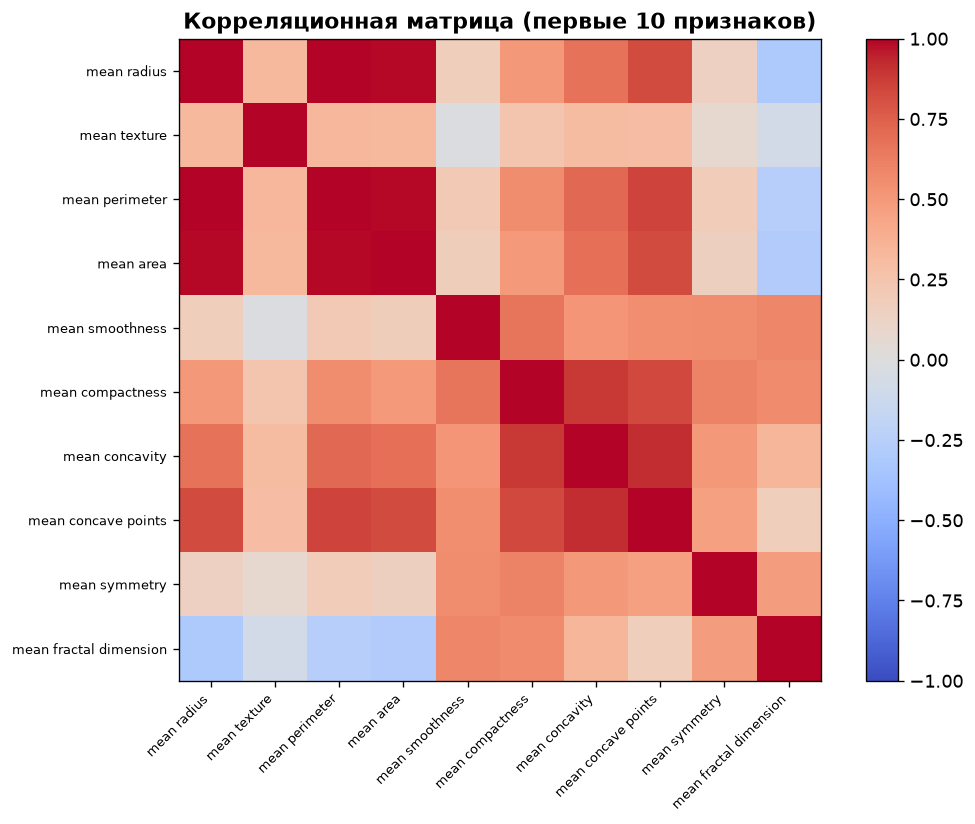

In [3]:
# Корреляционная тепловая карта первых 10 признаков
import numpy as np

feat10 = data.feature_names[:10]
corr = df[feat10].corr().values

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_xticklabels(feat10, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(feat10, fontsize=8)
ax.set_title("Корреляционная матрица (первые 10 признаков)", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Предобработка

In [4]:
X = data.data.values
y = data.target.values   # 0 = злокачественная, 1 = доброкачественная

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  позитивных: {y_train.mean():.1%}")
print(f"Test:  {X_test_sc.shape}   |  позитивных: {y_test.mean():.1%}")

Train: (455, 30)  |  позитивных: 62.6%
Test:  (114, 30)   |  позитивных: 63.2%


## 3. Обучение и кривые BCE

In [5]:
model_sgd = LogisticRegression(lr=0.1, epochs=500, batch_size=32)
model_sgd.fit(X_train_sc, y_train, method="sgd")

model_gd = LogisticRegression(lr=0.1, epochs=500)
model_gd.fit(X_train_sc, y_train, method="gd")

print(f"SGD accuracy (test): {model_sgd.score(X_test_sc, y_test):.4f}")
print(f"GD  accuracy (test): {model_gd.score(X_test_sc, y_test):.4f}")

Ранняя остановка на эпохе 340 (Δloss = 3.87e-07 < tol=1e-06)
SGD accuracy (test): 0.9825
GD  accuracy (test): 0.9737


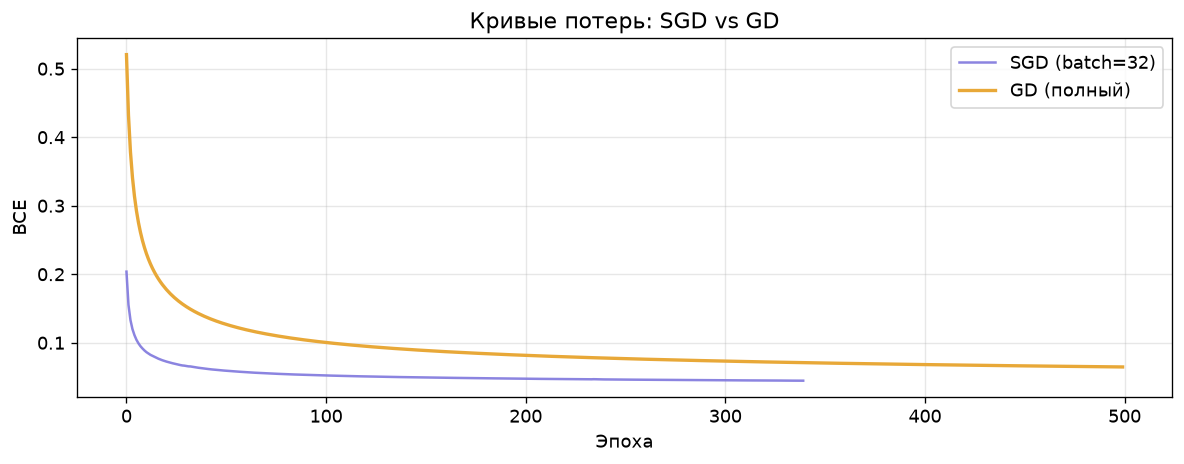

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(model_sgd.loss_history, label="SGD (batch=32)", color="#7F77DD", alpha=0.9)
ax.plot(model_gd.loss_history,  label="GD (полный)",    color="#E8A838", linewidth=2)
ax.set_xlabel("Эпоха"); ax.set_ylabel("BCE")
ax.set_title("Кривые потерь: SGD vs GD")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Влияние порога классификации

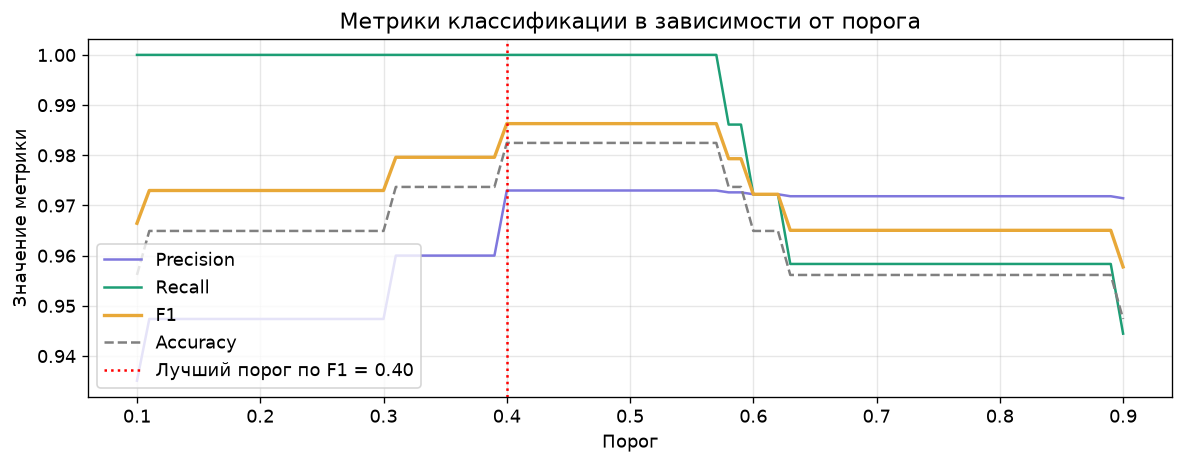

Оптимальный порог по F1: 0.40  →  F1=0.9863


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s, accs = [], [], [], []

for t in thresholds:
    preds = model_sgd.predict_class(X_test_sc, threshold=t)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))
    accs.append(np.mean(preds == y_test))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions, label="Precision", color="#7F77DD")
ax.plot(thresholds, recalls,   label="Recall",    color="#1D9E75")
ax.plot(thresholds, f1s,       label="F1",        color="#E8A838", linewidth=2)
ax.plot(thresholds, accs,      label="Accuracy",  color="gray", linestyle="--")

best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color="red", linestyle=":", linewidth=1.5,
           label=f"Лучший порог по F1 = {best_t:.2f}")
ax.set_xlabel("Порог"); ax.set_ylabel("Значение метрики")
ax.set_title("Метрики классификации в зависимости от порога")
ax.legend(loc="lower left"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Оптимальный порог по F1: {best_t:.2f}  →  F1={max(f1s):.4f}")

## 5. Матрица ошибок

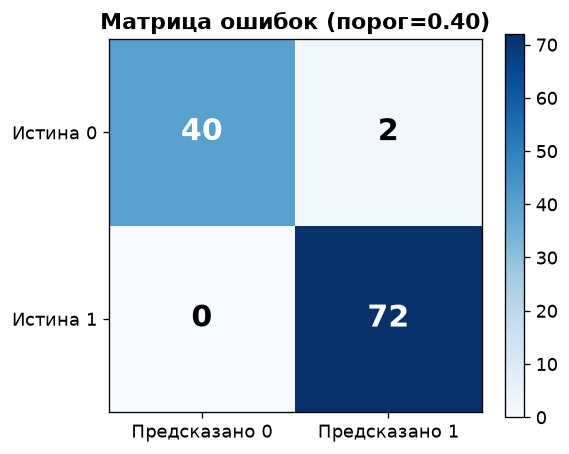

TP=72  TN=40  FP=2  FN=0
Precision: 0.9730  Recall: 1.0000
F1-score:  0.9863


In [8]:
from sklearn.metrics import confusion_matrix

best_preds = model_sgd.predict_class(X_test_sc, threshold=best_t)
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Предсказано 0", "Предсказано 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Истина 0", "Истина 1"])
ax.set_title(f"Матрица ошибок (порог={best_t:.2f})", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"Precision: {tp/(tp+fp):.4f}  Recall: {tp/(tp+fn):.4f}")
print(f"F1-score:  {2*tp/(2*tp+fp+fn):.4f}")

## Выводы

- Оба метода (SGD и GD) достигают высокой точности на датасете Breast Cancer.  
- **SGD** быстрее убывает в первых эпохах за счёт шумных обновлений; **GD** даёт гладкую кривую.  
- Порог 0.5 не всегда оптимален: при несбалансированных классах или асимметричных издержках ошибок рекомендуется подбирать порог по F1 или ROC-AUC.  
- В медицинской диагностике предпочтительнее минимизировать FN (пропущенные злокачественные случаи), что достигается снижением порога классификации.